# Análisis de Datos IV

In [ ]:
import pandas as pd

In [ ]:
# Importar base de datos de exoplanetas
data_url = "https://exoplanetarchive.ipac.caltech.edu/cgi-bin/nstedAPI/nph-nstedAPI?table=cumulative&select=koi_period,koi_sma,koi_smass&format=csv"
df_0 = pd.read_csv(data_url)

In [ ]:
# Eliminación de los renglones que contienen valores NaN
df_limpia=df_0.dropna().reset_index(drop=True)

In [ ]:
def filtro(base,col,factor):
  '''Función que elimina datos de las colas de la columna indicada de una base de datos determinando el indice intercuartílico
y seleccionando elementos que están por encima del tercer cuartil a una distancia indice_intercuartil*factor y elementos que están por abajo del segundo cuartil a la misma distancia'''
  indice_intercuartil=base[col].quantile(0.75)-base[col].quantile(0.25)
  filtro_inferior=base[col]>base[col].quantile(0.25)-(indice_intercuartil*factor)
  filtro_superior=base[col]<base[col].quantile(0.75)+(indice_intercuartil*factor)
  return base[filtro_inferior & filtro_superior]

In [ ]:
# Filtramos datos para quitar las colas de las tres variables de interés
df_l1=filtro(df_limpia,'koi_period',2)
df_l2=filtro(df_l1,'koi_sma',2)
df_1=filtro(df_l2,'koi_smass',2)

In [ ]:
df_1.head()

,koi_period,koi_sma,koi_smass
0,9.488036,0.0853,0.919
1,54.418383,0.2734,0.919
2,19.899140,0.1419,0.961
3,1.736952,0.0267,0.836
4,2.525592,0.0374,1.095


Matriz de Correlación de Pearson

In [ ]:
df_1.corr()

,koi_period,koi_sma,koi_smass
koi_period,1.000000,0.975239,-0.034591
koi_sma,0.975239,1.000000,0.058032
koi_smass,-0.034591,0.058032,1.000000


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

Text(0.5, 1.0, 'Matriz de Correlación de Pearson')

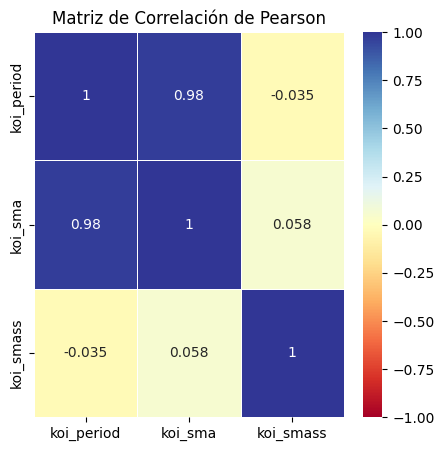

In [ ]:
from prompt_toolkit.shortcuts import set_title
plt.figure(figsize=(5,5))
eje_0=sns.heatmap(df_1.corr(), vmin=-1,vmax=1,annot=True,cmap="RdYlBu", linewidths=0.5)
eje_0.set_title('Matriz de Correlación de Pearson')

Tercera ley de Kepler:  $$T^2=\frac{k a^3}{M}$$, con $T$ como el período orbital, $a$ como el semieje mayor, $M$ como la masa de la estrella y $k$ una constante. Tomando el logaritmo natural en ambos lados de la ecuación anterior, obtenemos: $$2 \log T=\log k+3\log a-\log M.$$ Despejando el logaritmo de la masa $$\log M=\log k+3\log a-2 \log T$$

Conversión a Unidades del Sistema Internacional y toma del Logaritmo natural

In [ ]:
import numpy as np

In [ ]:
df_2=df_1.copy()

In [ ]:
df_2['ln_masa']=(df_1['koi_smass'].apply(lambda x: x*1.988416*10**30)).apply(np.log)

In [ ]:
df_2['ln_semi']=(df_1['koi_sma'].apply(lambda x: x*149597870700)).apply(np.log)

In [ ]:
df_2['ln_periodo']=(df_1['koi_period'].apply(lambda x: x*86400)).apply(np.log)

In [ ]:
df_2.head()

,koi_period,koi_sma,koi_smass,ln_masa,ln_semi,ln_periodo
0,9.488036,0.0853,0.919,69.680422,23.269636,13.616775
1,54.418383,0.2734,0.919,69.680422,24.434397,15.363445
2,19.899140,0.1419,0.961,69.725110,23.778584,14.357419
3,1.736952,0.0267,0.836,69.585764,22.108125,11.918875
4,2.525592,0.0374,1.095,69.855645,22.445132,12.293218


In [ ]:
df_3=df_2.drop(['koi_period','koi_sma','koi_smass'],axis=1)

In [ ]:
df_3.head()

,ln_masa,ln_semi,ln_periodo
0,69.680422,23.269636,13.616775
1,69.680422,24.434397,15.363445
2,69.725110,23.778584,14.357419
3,69.585764,22.108125,11.918875
4,69.855645,22.445132,12.293218


Ahora podemos verificar que existe una correlación lineal entre los logaritmos del período y el semieje

Text(0.5, 1.0, 'Matriz de Correlación de Pearson')

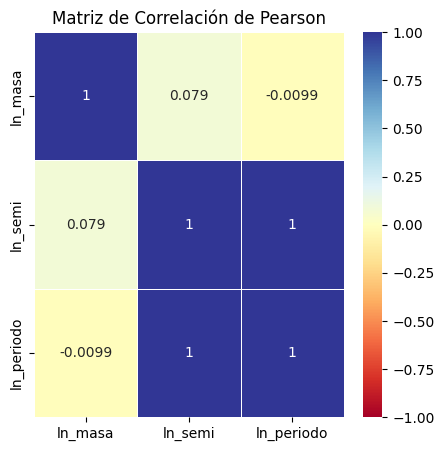

In [ ]:
plt.figure(figsize=(5,5))
eje_0=sns.heatmap(df_3.corr(), vmin=-1,vmax=1,annot=True,cmap="RdYlBu", linewidths=0.5)
eje_0.set_title('Matriz de Correlación de Pearson')

Ejemplo de Regresión Lineal

Primer paso: Identificar las variables independientes y dependientes

In [ ]:
X=df_3[['ln_semi','ln_periodo']] # Variables independientes
Y=df_3['ln_masa'] # Variable dependientes

Segundo paso: dividir nuestros datos en conjuntos de entrenamiento y de prueba

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
X_entrenamiento, X_prueba, Y_entrenamiento, Y_prueba=train_test_split(X,Y,test_size=0.3, shuffle=True)

Tercer paso: Hacer la regresión lineal múltiple

In [ ]:
from sklearn.linear_model import LinearRegression

In [ ]:
lr=LinearRegression()
lr.fit(X_entrenamiento,Y_entrenamiento)

LinearRegression()

Coeficientes de la regresión lineal

In [ ]:
# de acuerdo con la tercera ley de Kepler, estos valores deben ser 3 y -2
lr.coef_

array([ 2.93655201, -1.95799868])

In [ ]:
# log k
lr.intercept_

np.float64(28.00937633861774)

Evaluación de qué tan buena es la regresión lineal

In [ ]:
# Coeficiente de determinación de la regresión lineal con respecto a los conjuntos de datos de prueba
lr.score(X_prueba,Y_prueba)

0.9991013138532835

Predicciones del modelo

In [ ]:
ln_masa_prediccion=lr.predict(X)

Text(0, 0.5, 'log(M)')

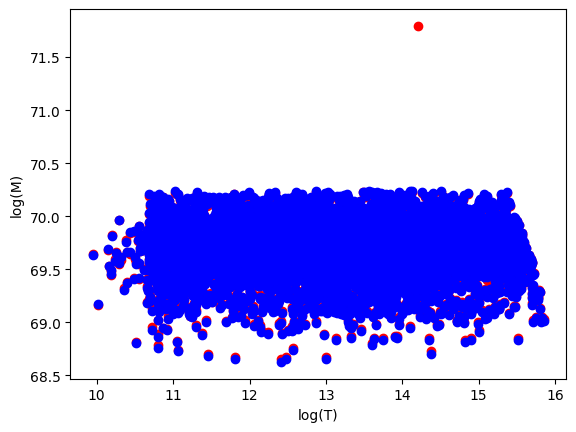

In [ ]:
plt.scatter(X['ln_periodo'],ln_masa_prediccion, c='r')
plt.scatter(X['ln_periodo'],Y, c='b')
plt.xlabel(r'log(T)')
plt.ylabel(r'log(M)')

Validación Cruzada


In [ ]:
from sklearn.model_selection import cross_validate

In [ ]:
rcuad=cross_validate(lr,X,Y, scoring='r2')
rcuad

{'fit_time': array([0.00452876, 0.00265574, 0.00262785, 0.00250077, 0.00261402]),
 'score_time': array([0.0021677 , 0.00198388, 0.00190425, 0.00188565, 0.00184941]),
 'test_score': array([0.99899925, 0.99906926, 0.99923022, 0.93933157, 0.99912898])}

In [ ]:
print(f'Nuestra regresión lineal arroja un R cuadrada promedio de {rcuad['test_score'].mean():.3f} +/- {rcuad['test_score'].std():.3f}')

Nuestra regresión lineal arroja un R cuadrada promedio de 0.987 +/- 0.024


Regresión lineal usando una red neuronal (de una sola neurona)

In [ ]:
import tensorflow as tf

In [ ]:
# Red neuronal artificial que admite un argumento de dos componentes
capa0=tf.keras.layers.Dense(units=1,input_dim=2,activation='linear')
model=tf.keras.Sequential([capa0])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.compile(loss='mean_squared_error',optimizer=tf.keras.optimizers.Adam(0.25),metrics=['mean_squared_error'])

In [ ]:
historia=model.fit(X_entrenamiento,Y_entrenamiento,epochs=100,verbose=True,validation_split=0.02)

Epoch 1/100
153/153 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 6.9539 - mean_squared_error: 6.9539 - val_loss: 0.0064 - val_mean_squared_error: 0.0064
Epoch 2/100
153/153 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0083 - mean_squared_error: 0.0083 - val_loss: 0.0061 - val_mean_squared_error: 0.0061
Epoch 3/100
153/153 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0078 - mean_squared_error: 0.0078 - val_loss: 0.0142 - val_mean_squared_error: 0.0142
Epoch 4/100
153/153 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0084 - mean_squared_error: 0.0084 - val_loss: 0.0058 - val_mean_squared_error: 0.0058
Epoch 5/100
153/153 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0130 - mean_squared_error: 0.0130 - val_loss: 0.0116 - val_mean_squared_error: 0.0116
Epoch 6/100
153/153 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0131 - mean_squared_error: 0.0131 - val_loss: 0.0097 - val_mean_squared_error: 0.0097
Epoch 7/100
153/153 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0115 - mean_squared_error: 0.0115 - val_los

In [ ]:
capa0.get_weights()

[array([[ 3.6453092],
        [-2.4269016]], dtype=float32),
 array([17.788069], dtype=float32)]